# ROI Sum Acceleration Benchmark

Benchmark ROI summing backends on synthetic Pilatus 6M images. The benchmark compares the NumPy reference path with the optional C++ and Numba acceleration backends when they are available. It also times the C++ fitted-background path using a second-order polynomial.

Each ROI has a signal region plus left, right, top, and bottom background strips. The counters include image signal/background, correction signal/background, background-image signal/background, and unmasked pixel counts. The accelerated strip-background counters are checked against NumPy before timing results are plotted.

The first accelerated call may include setup or compilation overhead, so the benchmark does an explicit warmup before recording timings. Reported per-image timings are runtime-only measurements after warmup.

## Setup

Run this notebook from either the repository root, the `benchmarks/` directory, or the `doc/source/benchmarks/` directory. The benchmark uses synthetic `float64` Pilatus 6M-shaped arrays and randomly generated center/background ROIs.

In [1]:
from pathlib import Path
from types import SimpleNamespace
import concurrent.futures
import importlib.util
import platform
import statistics
import sys
import tempfile
import time

import numpy as np


def find_repo_root(start=None):
    path = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "orgui").is_dir() and (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not find the orGUI repository root")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

BENCHMARK_PATH = REPO_ROOT / "benchmarks" / "benchmark_roi_sum_accel.py"
spec = importlib.util.spec_from_file_location("benchmark_roi_sum_accel", BENCHMARK_PATH)
roi_bench = importlib.util.module_from_spec(spec)
spec.loader.exec_module(roi_bench)

print(f"Repository: {REPO_ROOT}")
print(f"Benchmark:  {BENCHMARK_PATH}")

Repository: /home/tfuchs/src/orGUI
Benchmark:  /home/tfuchs/src/orGUI/benchmarks/benchmark_roi_sum_accel.py


In [2]:
!hostname

lnx325.classe.cornell.edu


In [3]:
from orgui import __version__

print("orGUI version", __version__)
print("Python", platform.python_version())
print("NumPy", np.__version__)

orGUI version 1.5.1.dev26+g271f8c024.d20260703
Python 3.13.11
NumPy 2.3.0


In [4]:
cpp_backend = roi_bench.import_cpp_backend()
backends = {
    "numpy": roi_bench.wrap_numpy_backend(),
    "cpp": roi_bench.wrap_backend(cpp_backend),
}
numba_backend = roi_bench.try_build_numba_backend()
if numba_backend is not None:
    backends["numba"] = roi_bench.wrap_backend(SimpleNamespace(**numba_backend))

print("Available ROI backends:", list(backends))
print("C++ backend:", getattr(cpp_backend, "__file__", "installed module"))
polybg_func = cpp_backend.processImage_polybg_Carr


Available ROI backends: ['numpy', 'cpp', 'numba']
C++ backend: /home/tfuchs/src/orGUI/build/cp313/_roi_sum_cpp.cpython-313-x86_64-linux-gnu.so


## Benchmark Helpers

The synthetic detector uses the Pilatus 6M image shape `(2527, 2463)`. User-facing ROI and background strip sizes are in pixels. The image, correction, and background-image arrays are `float64`, matching the accelerator-facing paths used by the GUI integration code.

The fitted-background benchmark uses the same center/background ROI geometry as the strip-background benchmark. Reported background size is the number of unmasked pixels in the four background strips used for each polynomial fit.

In [5]:
POLYBG_ORDER = 2
POLYBG_BACKEND = f"cpp_polybg_order{POLYBG_ORDER}"


def make_args(**overrides):
    values = {
        "seed": 12345,
        "repeats": 5,
        "rois": 50,
        "shape": roi_bench.PILATUS_6M_SHAPE,
        "roi_min": 10,
        "roi_max": 100,
        "bg_min": 5,
        "bg_max": 50,
        "signal_mean": 100.0,
        "background_min": 5.0,
        "background_max": 50.0,
        "mask_fraction": 0.01,
        "disk_images": 0,
        "threads": 1,
        "disk_dir": None,
        "json": None,
        "no_numba": False,
    }
    values.update(overrides)
    return SimpleNamespace(**values)


def format_seconds(value):
    if value < 1e-3:
        return f"{value * 1e6:8.1f} us"
    if value < 1:
        return f"{value * 1e3:8.2f} ms"
    return f"{value:8.3f} s"


def print_table(rows, columns):
    widths = {key: max(len(str(label)), *(len(str(row[key])) for row in rows)) for key, label in columns}
    print(" ".join(str(label).rjust(widths[key]) for key, label in columns))
    for row in rows:
        print(" ".join(str(row[key]).rjust(widths[key]) for key, _ in columns))


def run_one_polybg_backend(func, base_image, mask, correction, rois, order=POLYBG_ORDER):
    image = base_image.copy(order="C")
    all_counters = np.zeros((rois[0].shape[0], 4), dtype=np.float64)
    correction_counters = np.zeros_like(all_counters)
    start = time.perf_counter()
    func(image, mask, correction, *rois, all_counters, correction_counters, order)
    duration = time.perf_counter() - start
    return duration, (all_counters, correction_counters)


def benchmark_polybg_backend(func, base_image, mask, correction, rois, repeats, order=POLYBG_ORDER):
    warmup_duration, counters = run_one_polybg_backend(func, base_image, mask, correction, rois, order)
    timings = []
    for _ in range(repeats):
        duration, counters = run_one_polybg_backend(func, base_image, mask, correction, rois, order)
        timings.append(duration)
    return {
        "name": POLYBG_BACKEND,
        "warmup_seconds": warmup_duration,
        "median_seconds": statistics.median(timings),
        "min_seconds": min(timings),
        "max_seconds": max(timings),
        "counters": counters,
    }


def integrate_polybg_image(func, image, mask, correction, rois, order=POLYBG_ORDER):
    all_counters = np.zeros((rois[0].shape[0], 4), dtype=np.float64)
    correction_counters = np.zeros_like(all_counters)
    func(image, mask, correction, *rois, all_counters, correction_counters, order)
    return all_counters, correction_counters


def process_polybg_disk_image(path, func, mask, correction, rois, order=POLYBG_ORDER):
    image = np.load(path)
    return integrate_polybg_image(func, image, mask, correction, rois, order)


def background_pixel_counts(mask, rois):
    counts = np.zeros(rois[0].shape[0], dtype=np.int64)
    for roi_group in rois[1:]:
        for i, roi in enumerate(roi_group):
            ys = slice(roi[1, 0], roi[1, 1])
            xs = slice(roi[0, 0], roi[0, 1])
            counts[i] += np.count_nonzero(~mask[ys, xs])
    return counts


base_args = make_args()
print("Detector Pilatus 6M")
print("shape", base_args.shape)
print("roi_size_px", (base_args.roi_min, base_args.roi_max))
print("background_strip_px", (base_args.bg_min, base_args.bg_max))
print("background_counts", (base_args.background_min, base_args.background_max))
print("mask_fraction", base_args.mask_fraction)
print("repeats", base_args.repeats)
print("fitted_background_order", POLYBG_ORDER)


Detector Pilatus 6M
shape (2527, 2463)
roi_size_px (10, 100)
background_strip_px (5, 50)
background_counts (5.0, 50.0)
mask_fraction 0.01
repeats 5
fitted_background_order 2


## Correctness Check

The accelerated strip-background paths must reproduce the NumPy reference counters for image, correction, and background-image sums before any strip-background timing result is trusted. The fitted-background path is checked for finite counters and matching signal/background pixel counts, but its fitted background sum is not expected to equal the strip-sum background value.

In [6]:
args = make_args(rois=20, repeats=1)
image, background, mask, correction, rois = roi_bench.make_inputs(args)
reference = None
for name, func in backends.items():
    result = roi_bench.benchmark_backend(
        name,
        func,
        image,
        background,
        mask,
        correction,
        rois,
        repeats=1,
    )
    if name == "numpy":
        reference = result["counters"]
    else:
        roi_bench.check_results(reference, result["counters"], name)

_, polybg_counters = run_one_polybg_backend(polybg_func, image, mask, correction, rois)
np.testing.assert_allclose(polybg_counters[0][:, 1], reference[0][:, 1])
np.testing.assert_allclose(polybg_counters[0][:, 3], reference[0][:, 3])
assert np.isfinite(polybg_counters[0]).all()
assert np.isfinite(polybg_counters[1]).all()

print("Available accelerated ROI strip-background backends match NumPy counters")
print("C++ second-order fitted-background path returned finite counters with matching pixel counts")

Available accelerated ROI strip-background backends match NumPy counters
C++ second-order fitted-background path returned finite counters with matching pixel counts


## ROI Count Sweep

This measures one in-memory image for `1, 5, 20, 50, 100, 500` ROIs with background strips enabled. Median time is reported across five measured repeats after one warmup call per backend and ROI count.

`cpp_polybg_order2` uses the C++ fitted-background path with a second-order polynomial fit to the pixels in the four background strips. Its fitted background values are not expected to equal the strip-sum background values, so it is timed alongside the other paths but not validated against NumPy strip-background counters.

In [7]:
ROI_COUNTS = (1, 5, 20, 50, 100, 500)
roi_results = []

for n_rois in ROI_COUNTS:
    args = make_args(rois=n_rois)
    image, background, mask, correction, rois = roi_bench.make_inputs(args)
    bg_counts = background_pixel_counts(mask, rois)
    bg_total_px = int(bg_counts.sum())
    bg_median_px = float(np.median(bg_counts))
    bg_min_px = int(bg_counts.min())
    bg_max_px = int(bg_counts.max())

    reference = None
    row_results = {}
    for name, func in backends.items():
        result = roi_bench.benchmark_backend(
            name,
            func,
            image,
            background,
            mask,
            correction,
            rois,
            repeats=args.repeats,
        )
        if name == "numpy":
            reference = result["counters"]
        else:
            roi_bench.check_results(reference, result["counters"], f"{name} {n_rois} ROIs")
        counters = result.pop("counters")
        result["counter_checksum"] = float(sum(np.nansum(counter) for counter in counters))
        row_results[name] = result

    polybg_result = benchmark_polybg_backend(
        polybg_func,
        image,
        mask,
        correction,
        rois,
        repeats=args.repeats,
    )
    polybg_counters = polybg_result.pop("counters")
    polybg_result["counter_checksum"] = float(sum(np.nansum(counter) for counter in polybg_counters))
    row_results[POLYBG_BACKEND] = polybg_result

    numpy_median = row_results["numpy"]["median_seconds"]
    for name, result in row_results.items():
        roi_results.append(
            {
                "rois": n_rois,
                "backend": name,
                "median_s": result["median_seconds"],
                "min_s": result["min_seconds"],
                "warmup_s": result["warmup_seconds"],
                "speedup_vs_numpy": numpy_median / result["median_seconds"],
                "bg_total_px": bg_total_px,
                "bg_median_px": bg_median_px,
                "bg_min_px": bg_min_px,
                "bg_max_px": bg_max_px,
            }
        )

summary_rows = [
    {
        "rois": row["rois"],
        "backend": row["backend"],
        "bg_total": row["bg_total_px"],
        "bg_median": f"{row['bg_median_px']:.0f}",
        "bg_range": f"{row['bg_min_px']}-{row['bg_max_px']}",
        "median": format_seconds(row["median_s"]).strip(),
        "min": format_seconds(row["min_s"]).strip(),
        "speedup": f"{row['speedup_vs_numpy']:.2f}x",
    }
    for row in roi_results
]
print_table(
    summary_rows,
    (
        ("rois", "ROIs"),
        ("backend", "backend"),
        ("bg_total", "bg px total"),
        ("bg_median", "bg px/ROI median"),
        ("bg_range", "bg px/ROI range"),
        ("median", "median"),
        ("min", "min"),
        ("speedup", "speedup"),
    ),
)


ROIs           backend bg px total bg px/ROI median bg px/ROI range    median       min speedup
   1             numpy        5173             5173       5173-5173   7.41 ms   7.22 ms   1.00x
   1               cpp        5173             5173       5173-5173  104.6 us  102.7 us  70.87x
   1             numba        5173             5173       5173-5173   5.40 ms   5.39 ms   1.37x
   1 cpp_polybg_order2        5173             5173       5173-5173  285.7 us  262.2 us  25.95x
   5             numpy       30432             5178       2889-9989  10.00 ms   9.99 ms   1.00x
   5               cpp       30432             5178       2889-9989  448.7 us  441.2 us  22.29x
   5             numba       30432             5178       2889-9989   6.10 ms   6.07 ms   1.64x
   5 cpp_polybg_order2       30432             5178       2889-9989   1.52 ms   1.50 ms   6.58x
  20             numpy      121378             5765       543-11579  19.76 ms  19.70 ms   1.00x
  20               cpp      121378      

## ROI Count Results

The runtime plot uses a log y-axis because the NumPy and accelerated paths differ by orders of magnitude for small ROI counts. The speedup plot is normalized to the NumPy median for the same ROI count.

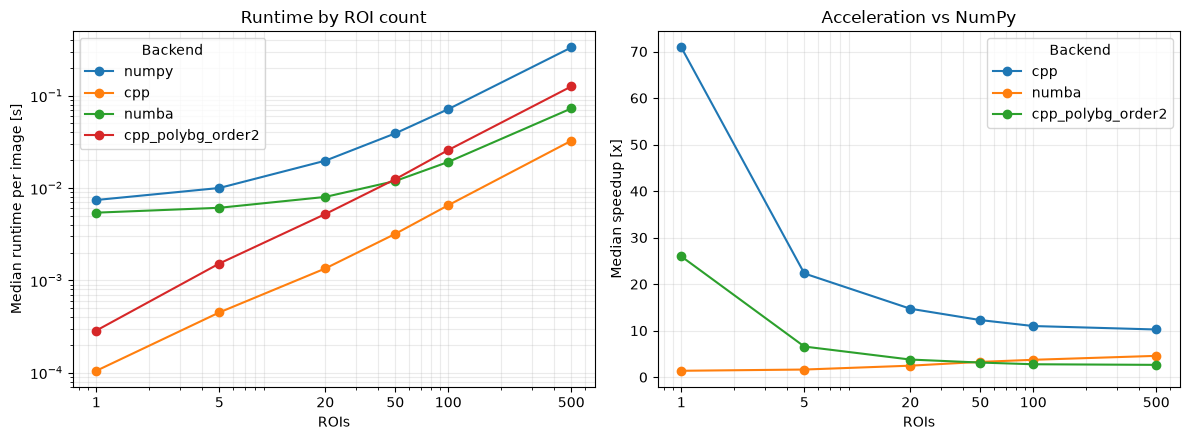

In [8]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax_time, ax_speedup = axes
plot_backends = list(backends) + [POLYBG_BACKEND]

for backend in plot_backends:
    rows = [row for row in roi_results if row["backend"] == backend]
    ax_time.plot(
        [row["rois"] for row in rows],
        [row["median_s"] for row in rows],
        marker="o",
        label=backend,
    )
    if backend != "numpy":
        ax_speedup.plot(
            [row["rois"] for row in rows],
            [row["speedup_vs_numpy"] for row in rows],
            marker="o",
            label=backend,
        )

ax_time.set_title("Runtime by ROI count")
ax_time.set_xlabel("ROIs")
ax_time.set_ylabel("Median runtime per image [s]")
ax_time.set_xscale("log")
ax_time.set_yscale("log")
ax_time.set_xticks(ROI_COUNTS)
ax_time.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax_time.grid(which="both", alpha=0.25)
ax_time.legend(title="Backend")

ax_speedup.set_title("Acceleration vs NumPy")
ax_speedup.set_xlabel("ROIs")
ax_speedup.set_ylabel("Median speedup [x]")
ax_speedup.set_xscale("log")
ax_speedup.set_xticks(ROI_COUNTS)
ax_speedup.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax_speedup.grid(which="both", alpha=0.25)
ax_speedup.legend(title="Backend")

fig.tight_layout()

## Threaded Disk-Image Sweep

This measures reading 50 synthetic `.npy` images from disk and integrating each image with 50 ROIs plus background strips. The same serial baseline is reused for each backend, then the workload is repeated with `1, 2, 4, 8` worker threads.

The fitted-background rows use the C++ second-order polynomial path and the same background-strip pixels reported in the table.

In [9]:
THREAD_COUNTS = (1, 2, 4, 8)
DISK_IMAGES = 50
THREAD_ROIS = 50
thread_results = []

thread_args = make_args(rois=THREAD_ROIS, disk_images=DISK_IMAGES)
image, background, mask, correction, rois = roi_bench.make_inputs(thread_args)
bg_counts = background_pixel_counts(mask, rois)
thread_bg_total_px = int(bg_counts.sum())
thread_bg_median_px = float(np.median(bg_counts))
thread_bg_min_px = int(bg_counts.min())
thread_bg_max_px = int(bg_counts.max())

with tempfile.TemporaryDirectory() as tmp:
    disk_dir = Path(tmp)
    image_paths = roi_bench.make_disk_images(thread_args, disk_dir)
    print(f"Disk image directory: {disk_dir}")
    print("Disk image format: .npy float64")
    print(f"Background pixels total per image: {thread_bg_total_px}")
    print(
        "Background pixels per ROI: "
        f"median {thread_bg_median_px:.0f}, range {thread_bg_min_px}-{thread_bg_max_px}"
    )

    disk_backend_specs = [(name, func, "strip") for name, func in backends.items()]
    disk_backend_specs.append((POLYBG_BACKEND, polybg_func, "polybg"))

    for backend, func, mode in disk_backend_specs:
        start = time.perf_counter()
        if mode == "polybg":
            serial_counters = [
                process_polybg_disk_image(path, func, mask, correction, rois)
                for path in image_paths
            ]
        else:
            serial_counters = [
                roi_bench.process_disk_image(path, func, background, mask, correction, rois)
                for path in image_paths
            ]
        serial_s = time.perf_counter() - start
        serial_checksum = roi_bench.checksum_counters(serial_counters)

        for threads in THREAD_COUNTS:
            start = time.perf_counter()
            with concurrent.futures.ThreadPoolExecutor(max_workers=threads) as executor:
                if mode == "polybg":
                    futures = [
                        executor.submit(
                            process_polybg_disk_image,
                            path,
                            func,
                            mask,
                            correction,
                            rois,
                        )
                        for path in image_paths
                    ]
                else:
                    futures = [
                        executor.submit(
                            roi_bench.process_disk_image,
                            path,
                            func,
                            background,
                            mask,
                            correction,
                            rois,
                        )
                        for path in image_paths
                    ]
                threaded_counters = [future.result() for future in futures]
            threaded_s = time.perf_counter() - start

            for i, (serial, threaded) in enumerate(zip(serial_counters, threaded_counters, strict=True)):
                if mode == "polybg":
                    for expected, actual in zip(serial, threaded, strict=True):
                        np.testing.assert_allclose(actual, expected, rtol=1e-12, atol=1e-9)
                else:
                    roi_bench.check_results(serial, threaded, f"{backend} threaded image {i}")

            thread_results.append(
                {
                    "backend": backend,
                    "threads": threads,
                    "images": DISK_IMAGES,
                    "rois": THREAD_ROIS,
                    "serial_s": serial_s,
                    "threaded_s": threaded_s,
                    "thread_speedup": serial_s / threaded_s,
                    "threaded_images_per_s": DISK_IMAGES / threaded_s,
                    "bg_total_px": thread_bg_total_px,
                    "bg_median_px": thread_bg_median_px,
                    "bg_min_px": thread_bg_min_px,
                    "bg_max_px": thread_bg_max_px,
                    "serial_checksum": serial_checksum,
                    "threaded_checksum": roi_bench.checksum_counters(threaded_counters),
                }
            )

summary_rows = [
    {
        "backend": row["backend"],
        "threads": row["threads"],
        "bg_total": row["bg_total_px"],
        "bg_median": f"{row['bg_median_px']:.0f}",
        "bg_range": f"{row['bg_min_px']}-{row['bg_max_px']}",
        "serial": format_seconds(row["serial_s"]).strip(),
        "threaded": format_seconds(row["threaded_s"]).strip(),
        "gain": f"{row['thread_speedup']:.2f}x",
        "ips": f"{row['threaded_images_per_s']:.2f}",
    }
    for row in thread_results
]
print_table(
    summary_rows,
    (
        ("backend", "backend"),
        ("threads", "threads"),
        ("bg_total", "bg px total"),
        ("bg_median", "bg px/ROI median"),
        ("bg_range", "bg px/ROI range"),
        ("serial", "serial"),
        ("threaded", "threaded"),
        ("gain", "thread_gain"),
        ("ips", "images/s"),
    ),
)


Disk image directory: /tmp/tmpga6a51hn
Disk image format: .npy float64
Background pixels total per image: 284650
Background pixels per ROI: median 5781, range 544-11879


          backend threads bg px total bg px/ROI median bg px/ROI range  serial  threaded thread_gain images/s
            numpy       1      284650             5781       544-11879 2.802 s   2.781 s       1.01x    17.98
            numpy       2      284650             5781       544-11879 2.802 s   2.686 s       1.04x    18.62
            numpy       4      284650             5781       544-11879 2.802 s   2.356 s       1.19x    21.23
            numpy       8      284650             5781       544-11879 2.802 s   2.475 s       1.13x    20.20
              cpp       1      284650             5781       544-11879 1.047 s   1.032 s       1.01x    48.46
              cpp       2      284650             5781       544-11879 1.047 s 558.92 ms       1.87x    89.46
              cpp       4      284650             5781       544-11879 1.047 s 327.50 ms       3.20x   152.67
              cpp       8      284650             5781       544-11879 1.047 s 281.95 ms       3.71x   177.34
          

## Threaded Results

The left plot shows end-to-end time for 50 disk-backed images. The right plot shows throughput for the same workload.

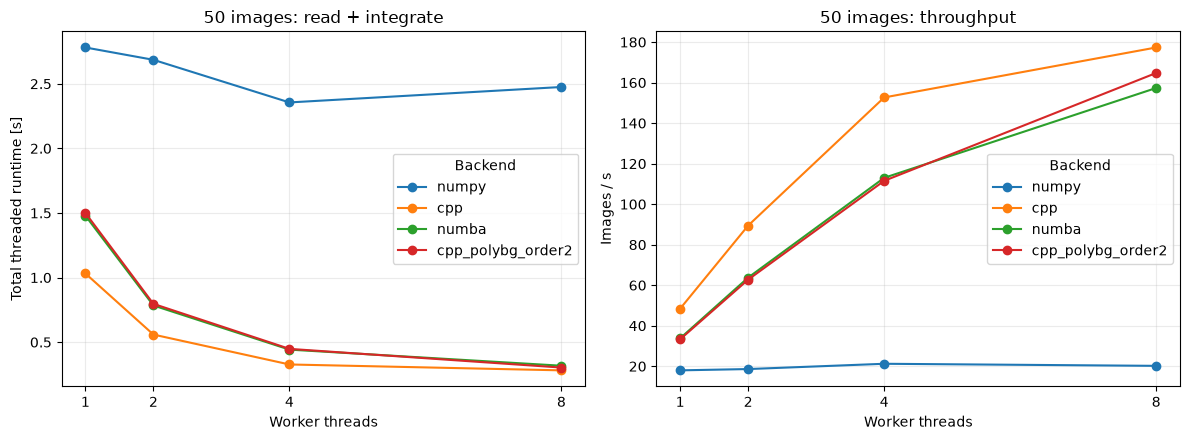

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax_time, ax_rate = axes

for backend in plot_backends:
    rows = [row for row in thread_results if row["backend"] == backend]
    ax_time.plot(
        [row["threads"] for row in rows],
        [row["threaded_s"] for row in rows],
        marker="o",
        label=backend,
    )
    ax_rate.plot(
        [row["threads"] for row in rows],
        [row["threaded_images_per_s"] for row in rows],
        marker="o",
        label=backend,
    )

ax_time.set_title("50 images: read + integrate")
ax_time.set_xlabel("Worker threads")
ax_time.set_ylabel("Total threaded runtime [s]")
ax_time.set_xticks(THREAD_COUNTS)
ax_time.grid(alpha=0.25)
ax_time.legend(title="Backend")

ax_rate.set_title("50 images: throughput")
ax_rate.set_xlabel("Worker threads")
ax_rate.set_ylabel("Images / s")
ax_rate.set_xticks(THREAD_COUNTS)
ax_rate.grid(alpha=0.25)
ax_rate.legend(title="Backend")

fig.tight_layout()